<a href="https://colab.research.google.com/github/shagun30107-bit/csot-ml-astronomy/blob/main/WEEK4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP-0

In [33]:
!pip install -U transformers

In [34]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device= "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# STEP-1

In [35]:
from datasets import load_dataset
ds_train = load_dataset('mwalmsley/euclid_strong_lens_expert_judges','classification',split='train')
ds_test = load_dataset('mwalmsley/euclid_strong_lens_expert_judges','classification',split='test')
print(ds_train)
print(ds_test)


Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 5876
})
Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 1476
})


# STEP-2

In [36]:
y_train = np.array(ds_train['label'])
y_test = np.array(ds_test['label'])
print('train:',len(y_train), 'test:',len(y_test))
print('train label counts:',np.bincount(y_train))
print('test label counts:',np.bincount(y_test))
print('test positive fraction:', y_test.mean())


train: 5876 test: 1476
train label counts: [5482  394]
test label counts: [1372  104]
test positive fraction: 0.07046070460704607


# STEP-3

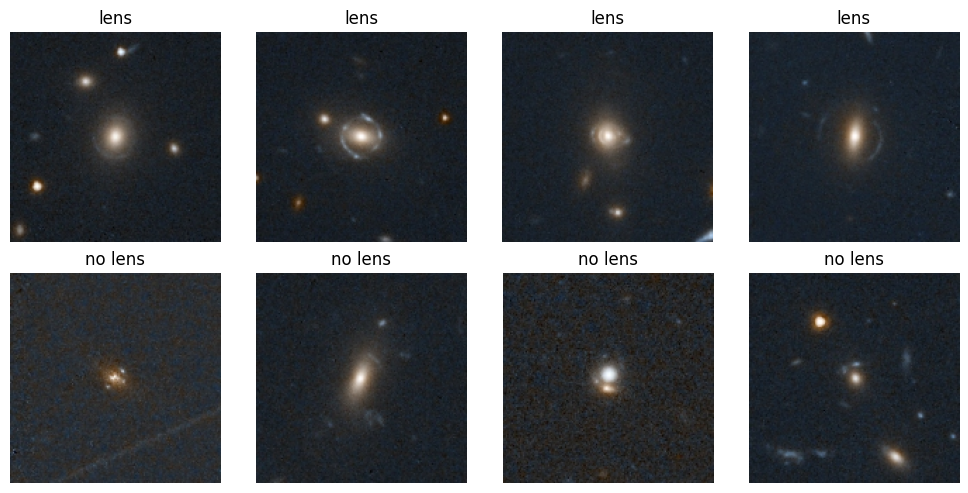

In [37]:
pos_idx = []
neg_idx = []

for i, y in enumerate(ds_test['label']):
    if y == 1 and len(pos_idx) < 4:
        pos_idx.append(i)
    elif y == 0 and len(neg_idx) < 4:
        neg_idx.append(i)

    if len(pos_idx) == 4 and len(neg_idx) == 4:
        break

fig,axes = plt.subplots(2,4,figsize=(10,5))
for ax,i in zip(axes[0], pos_idx):
  ax.imshow(ds_test[i]['image'])
  ax.set_title('lens')
  ax.axis('off')

for ax,i in zip(axes[1], neg_idx):
  ax.imshow(ds_test[i]['image'])
  ax.set_title('no lens')
  ax.axis('off')

plt.tight_layout()
plt.show()


# STEP-4

In [38]:
from transformers import CLIPModel, CLIPProcessor

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.to(device).eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print('LOaded on:',device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

LOaded on: cuda


# STEP-5

In [39]:
import torch.nn.functional as F
lens_prompts = [
      'a strong gravitational lens with an Einstein ring',
      'a gravitational lens arc next to a galaxy',
      'multiple images of a background source due to gravitational lensing']
nonlens_prompts = [
      'a normal galaxy without gravitational lensing',
      'a spiral galaxy with curved arms but no gravitational lens arc',
      'a smooth elliptical galaxy with no lensing features']
all_prompts = lens_prompts + nonlens_prompts
text_inputs = processor(text=all_prompts, return_tensors='pt', padding=True).to(device)

with torch.no_grad():
    outputs = model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"]
    )

text_emb = outputs.pooler_output
text_emb = F.normalize(text_emb, dim=-1)
n_lens = len(lens_prompts)


# STEP-6

In [40]:
images = [ex.convert('RGB') for ex in ds_test['image']]
img_embs = []
batch = 64

for start in range(0, len(images), batch):
    chunk = images[start:start+batch]
    inputs = processor(images=chunk, return_tensors='pt').to(device)

    with torch.no_grad():
      outputs = model.vision_model(pixel_values=inputs["pixel_values"])
      emb = model.visual_projection(outputs.pooler_output)   # 768 -> 512

    emb = F.normalize(emb, dim=-1)
    img_embs.append(emb.cpu())

img_emb = torch.cat(img_embs)
print(img_emb.shape)

torch.Size([1476, 512])


# STEP-7

In [41]:
sims = img_emb @ text_emb.cpu().T
lens_sim = sims[:, :n_lens].mean(dim=1)
nonlens_sim = sims[:, n_lens:].mean(dim=1)
scores = (lens_sim - nonlens_sim).numpy()
print('score range:', scores.min(), scores.max())



score range: -0.018972658 0.037896518


# STEP-8

ROC-auc: 0.562


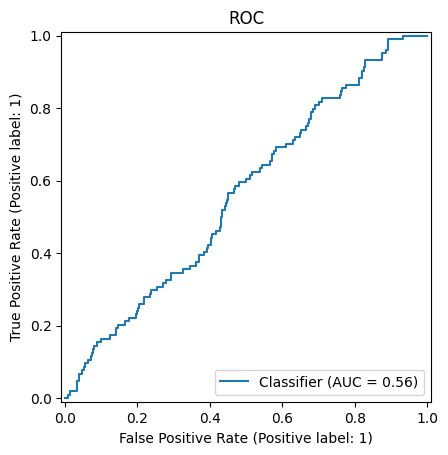

threshold t= 0.023173
              precision    recall  f1-score   support

        lens       0.93      0.90      0.92      1372
    not lens       0.11      0.15      0.13       104

    accuracy                           0.85      1476
   macro avg       0.52      0.53      0.52      1476
weighted avg       0.88      0.85      0.86      1476



In [42]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay, classification_report
auc = roc_auc_score(y_test, scores)
print('ROC-auc:', round(auc,3))
RocCurveDisplay.from_predictions(y_test, scores)
plt.title('ROC')
plt.show()

t= np.quantile(scores, 0.90)
pred = (scores >= t).astype(int)
print(f'threshold t= {t:4f}')

print(classification_report(y_test, pred ,target_names=['lens','not lens']))


# STEP-9

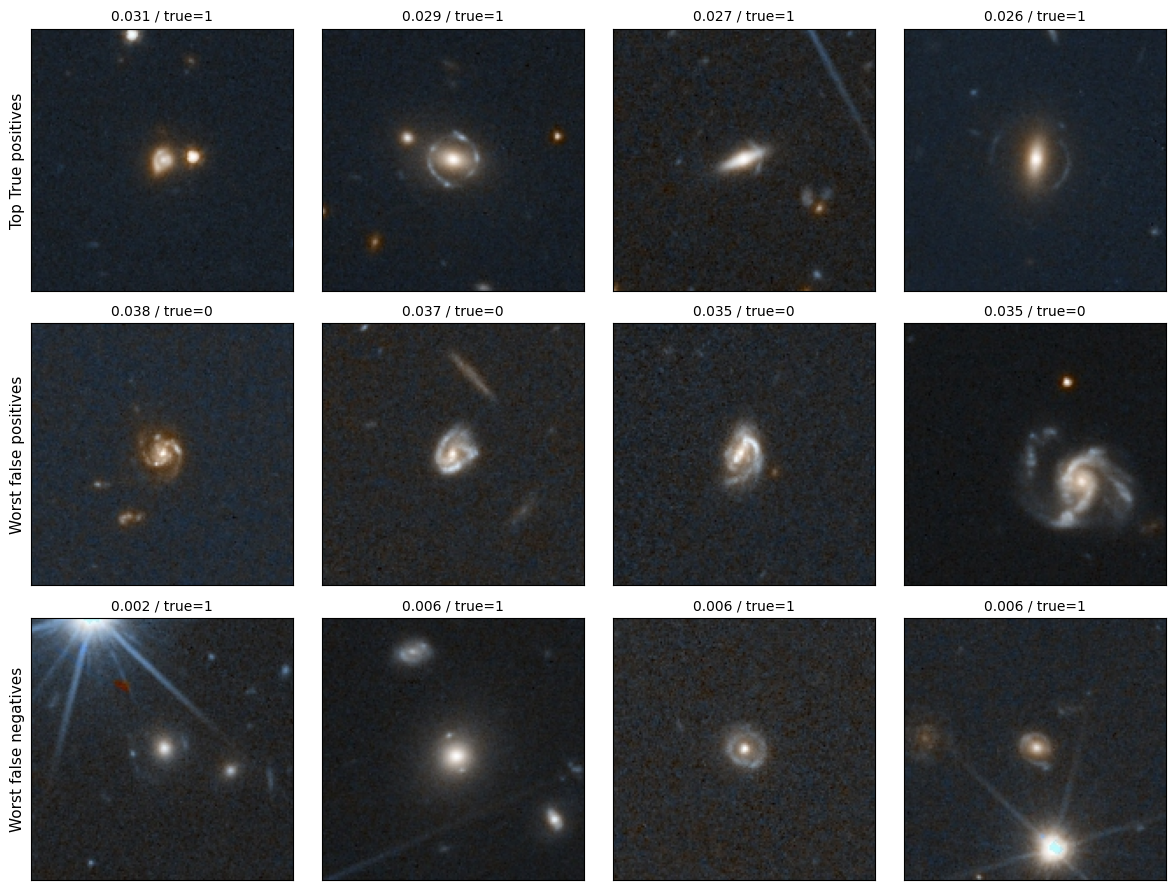

In [43]:
order = np.argsort(-scores)
y = np.array(y_test)

top_tp = [int(i) for i in order if y[i] == 1][:4]
worst_fn = [int(i) for i in order[::-1] if y[i] == 1][:4]
worst_fp = [int(i) for i in order if y[i] == 0][:4]

rows = [('Top True positives', top_tp),
        ('Worst false positives', worst_fp),
        ('Worst false negatives', worst_fn)]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for (title, idxs), row in zip(rows, axes):
    row[0].set_ylabel(title, fontsize=11)
    for ax, i in zip(row, idxs):
        i = int(i)
        ax.imshow(ds_test[i]['image'])
        ax.set_title(f'{scores[i]:.3f} / true={y[i]}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()
